
 How has Zimbabwe's electricity generation changed since 2000, and how does its mix compare with South Africa, Zambia and Mozambique?

**Data:** Ember, Yearly Electricity Data - https://ember-energy.org/data/yearly-electricity-data/

**Author:** Charlene Muchechesi

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Data/Raw/release_generation_yearly_global.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(104203, 24)
['Area', 'ISO 3 code', 'Year', 'Area type', 'Electricity source', 'Is aggregated source', 'Generation (TWh)', 'Generation YoY change (TWh)', 'Generation YoY change (%)', 'Share of generation (%)', 'Share of generation YoY change (% points)', 'Capacity (GW)', 'Emissions (MtCO2e)', 'Emissions YoY change (MtCO2e)', 'Emissions YoY change (%)', 'Share of emissions (%)', 'Emissions intensity (gCO2e/kWh)', 'Continent', 'Ember region', 'EU member', 'OECD member', 'G20 member', 'G7 member', 'ASEAN member']


,Area,ISO 3 code,Year,Area type,Electricity source,Is aggregated source,Generation (TWh),Generation YoY change (TWh),Generation YoY change (%),Share of generation (%),...,Emissions YoY change (%),Share of emissions (%),Emissions intensity (gCO2e/kWh),Continent,Ember region,EU member,OECD member,G20 member,G7 member,ASEAN member
0,ASEAN,NaN,2000,Region,Solar,False,0.070,NaN,NaN,0.016,...,NaN,0.001,42.857,NaN,NaN,False,False,False,False,False
1,ASEAN,NaN,2000,Region,Wind,False,0.000,NaN,NaN,0.000,...,NaN,0.000,NaN,NaN,NaN,False,False,False,False,False
2,ASEAN,NaN,2000,Region,Hydro,False,53.330,NaN,NaN,12.540,...,NaN,0.506,23.758,NaN,NaN,False,False,False,False,False
3,ASEAN,NaN,2000,Region,Bioenergy,False,10.797,NaN,NaN,2.539,...,NaN,0.934,216.819,NaN,NaN,False,False,False,False,False
4,ASEAN,NaN,2000,Region,Other renewables,False,16.928,NaN,NaN,3.980,...,NaN,0.254,37.630,NaN,NaN,False,False,False,False,False


In [4]:
zim = df[df["Area"] == "Zimbabwe"]
print(zim.shape)
print(zim["Year"].min(), zim["Year"].max())
print(zim["Electricity source"].unique())

(425, 24)
2000 2024
<StringArray>
[                                'Solar',
                                  'Wind',
                                 'Hydro',
                             'Bioenergy',
                      'Other renewables',
                               'Nuclear',
                                  'Coal',
                                   'Gas',
                          'Other fossil',
                           'Net imports',
                        'Wind and solar',
 'Hydro, bioenergy and other renewables',
                            'Renewables',
                                 'Clean',
                                'Fossil',
                      'Total generation',
                                'Demand']
Length: 17, dtype: str



Cleaning the data. Some rows are totals (for example "all fossil"). Keeping them would count the same electricity twice.

In [5]:
clean = zim[zim["Is aggregated source"] == False]
mix = clean.pivot_table(index="Year", columns="Electricity source", values="Generation (TWh)")
mix.tail()

Electricity source,Bioenergy,Coal,Gas,Hydro,Net imports,Nuclear,Other fossil,Other renewables,Solar,Wind
Year,,,,,,,,,,
2020,0.10,2.74,0.0,3.81,1.98,0.0,0.04,0.0,0.02,0.0
2021,0.11,2.51,0.0,5.93,1.74,0.0,0.00,0.0,0.02,0.0
2022,0.11,2.92,0.0,5.88,1.91,0.0,0.00,0.0,0.03,0.0
2023,0.12,4.38,0.0,5.46,2.00,0.0,0.00,0.0,0.03,0.0
2024,0.12,4.40,0.0,5.70,1.84,0.0,0.00,0.0,0.04,0.0



Stiill cleaning. We have net imports is electricity bought from other countries, not generated in Zimbabwe, so we separate it.

In [6]:
gen = mix.drop(columns="Net imports")
gen = gen.loc[:, gen.sum() > 0]

assert mix.index.is_unique, "Duplicate years found!"
assert (gen.fillna(0) >= 0).all().all(), "Negative generation found!"
print("Years:", mix.index.min(), "to", mix.index.max())
print(gen.isna().sum())

Years: 2000 to 2024
Electricity source
Bioenergy       0
Coal            0
Hydro           0
Other fossil    0
Solar           0
dtype: int64


Zimbabwe's electricity by source

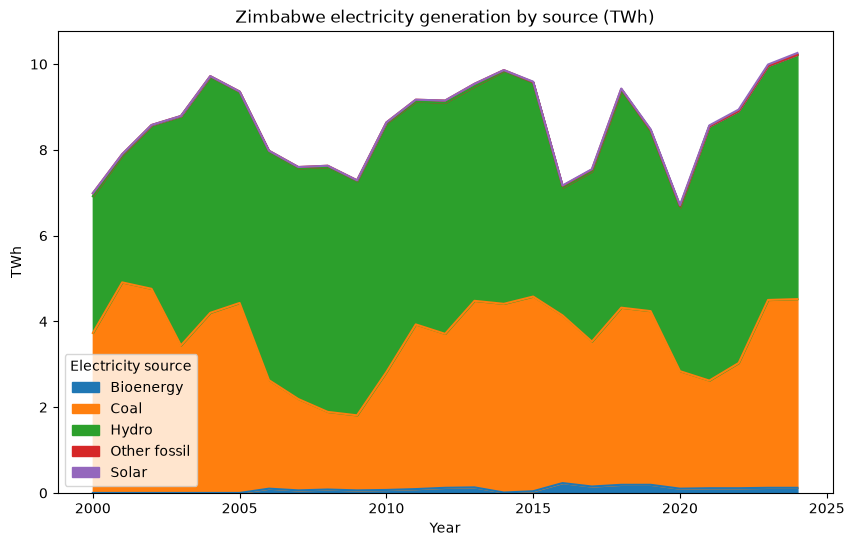

In [7]:
charts_folder = "Charts"
os.makedirs(charts_folder, exist_ok=True)

gen.plot.area(figsize=(10, 6), title="Zimbabwe electricity generation by source (TWh)")
plt.ylabel("TWh")
plt.savefig(os.path.join(charts_folder, "zimbabwe_mix.png"), dpi=150, bbox_inches="tight")
plt.show()

A comparison of Zimbabwe with her neighbours.

In [8]:
countries = ["Zimbabwe", "South Africa", "Zambia", "Mozambique"]

peers = df[
    (df["Area"].isin(countries))
    & (df["Is aggregated source"] == False)
    & (df["Year"] == 2024)
    & (df["Electricity source"] != "Net imports")
]
print(peers["Area"].unique())

table = peers.pivot_table(index="Area", columns="Electricity source", values="Generation (TWh)")
shares = table.div(table.sum(axis=1), axis=0) * 100
shares = shares.loc[:, shares.sum() > 0]
print(shares.round(1))

<StringArray>
['Mozambique', 'South Africa', 'Zambia', 'Zimbabwe']
Length: 4, dtype: str
Electricity source  Bioenergy  Coal   Gas  Hydro  Nuclear  Other fossil  \
Area                                                                      
Mozambique                0.7   0.0  15.8   82.4      0.0           0.8   
South Africa              0.2  83.6   0.0    0.4      3.2           0.8   
Zambia                    0.4  10.8   0.0   86.2      0.0           1.7   
Zimbabwe                  1.2  42.9   0.0   55.6      0.0           0.0   

Electricity source  Solar  Wind  
Area                             
Mozambique            0.4   0.0  
South Africa          7.4   4.5  
Zambia                0.9   0.0  
Zimbabwe              0.4   0.0  


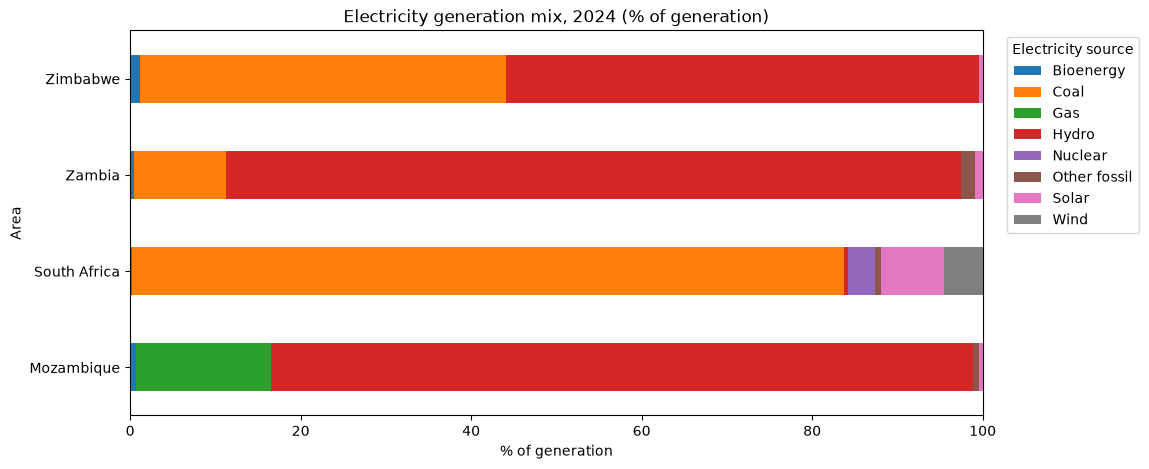

In [9]:
ax = shares.plot.barh(stacked=True, figsize=(11, 5), title="Electricity generation mix, 2024 (% of generation)")
ax.legend(title="Electricity source", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xlabel("% of generation")
plt.savefig(os.path.join(charts_folder, "peer_mix_2024.png"), dpi=150, bbox_inches="tight")
plt.show()

Saving the data

In [10]:
clean_folder = os.path.join("Data", "Clean")
os.makedirs(clean_folder, exist_ok=True)
gen.to_csv(os.path.join(clean_folder, "zimbabwe_generation_clean.csv"))

Key findings are in the README. 

Some of the Limitation noted are:
- Shares exclude net imports, which are material for Zimbabwe (about 1.8 TWh a year), so "share of generation" is not "share of consumption".
- Small-scale and off-grid solar may not be captured in this dataset.